# 02 - Curve Bootstrap and Forward Rates
Load sample Treasury inputs, bootstrap a spot curve, derive forward rates, and visualize both.

### Learning goals
- Interpret spot rates as discounting inputs for valuation.
- Convert spot information into forward-rate segments.
- Export curve artifacts for downstream portfolio risk analysis.

### Analytical question
What does the shape of the spot and forward curves imply about the rates environment and potential carry/hedge choices?

### Method vs alternative
- **Method used:** direct transformation of sample Treasury yields into spot and adjacent-segment forward rates.
- **Alternative:** market-convention bootstrap using instrument-specific cash flows and calendars.
- **Tradeoff:** current method is transparent for learning and communication; alternative improves precision.

### Assumptions and limitations
| Assumption | Limitation impact | Next enhancement |
|---|---|---|
| Yields directly map to zero rates | Can understate convention effects | Add tenor-specific instrument bootstrap |
| Adjacent forward segments only | Coarse forward structure | Add interpolated forward grid |
| Static snapshot of one curve date | No trend context | Add historical curve panel and regime labels |

### How to read the outputs
- Spot curve level and slope summarize the current rates environment.
- Forward segments provide implied market expectations across adjacent maturities.
- Curve files are reusable inputs for risk/scenario workflows in notebook 03.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve().parent
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from fixed_income_toolkit.io import read_treasuries_csv
from fixed_income_toolkit.curve import bootstrap_spot_curve, derive_forward_curve

treasury_path = repo_root / "data" / "sample" / "treasuries.csv"

In [2]:
instruments = read_treasuries_csv(treasury_path)
spot_points = bootstrap_spot_curve(instruments)
fwd_points = derive_forward_curve(spot_points)

spot_df = pd.DataFrame({
    "tenor_years": [p.tenor_years for p in spot_points],
    "zero_rate": [p.zero_rate for p in spot_points],
    "discount_factor": [p.discount_factor for p in spot_points],
})

fwd_df = pd.DataFrame({
    "start_tenor": [p.start_tenor for p in fwd_points],
    "end_tenor": [p.end_tenor for p in fwd_points],
    "forward_rate": [p.forward_rate for p in fwd_points],
})

spot_df, fwd_df.head()

(   tenor_years  zero_rate  discount_factor
 0          0.5     0.0420         0.979639
 1          1.0     0.0410         0.960227
 2          2.0     0.0405         0.922940
 3          5.0     0.0400         0.820348
 4         10.0     0.0415         0.663151
 5         30.0     0.0430         0.279060,
    start_tenor  end_tenor  forward_rate
 0          0.5        1.0      0.040841
 1          1.0        2.0      0.040400
 2          2.0        5.0      0.040060
 3          5.0       10.0      0.043463
 4         10.0       30.0      0.044229)

### Step 2: Visual diagnostics
The first chart shows level/shape of the spot curve, and the second chart shows implied forwards between tenor buckets.

Interpretation: focus on inflection points and steepness changes to discuss carry opportunities and hedge-tenor selection.

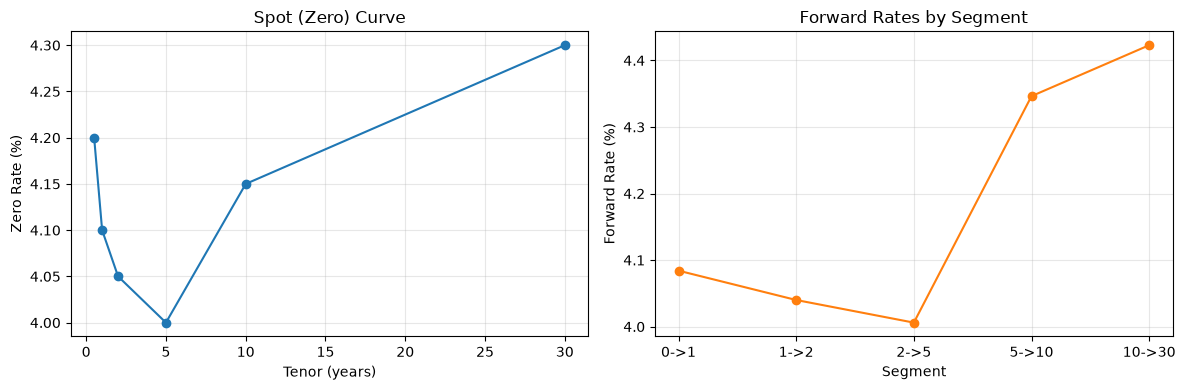

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(spot_df["tenor_years"], spot_df["zero_rate"] * 100, marker="o")
ax[0].set_title("Spot (Zero) Curve")
ax[0].set_xlabel("Tenor (years)")
ax[0].set_ylabel("Zero Rate (%)")
ax[0].grid(alpha=0.3)

if not fwd_df.empty:
    fwd_x = [f"{int(s)}->{int(e)}" for s, e in zip(fwd_df["start_tenor"], fwd_df["end_tenor"])]
    ax[1].plot(fwd_x, fwd_df["forward_rate"] * 100, marker="o", color="tab:orange")
ax[1].set_title("Forward Rates by Segment")
ax[1].set_xlabel("Segment")
ax[1].set_ylabel("Forward Rate (%)")
ax[1].grid(alpha=0.3)
plt.tight_layout()

In [4]:
outputs_dir = repo_root / "outputs"
outputs_dir.mkdir(exist_ok=True)
spot_df.to_csv(outputs_dir / "spot_curve_from_notebook.csv", index=False)
fwd_df.to_csv(outputs_dir / "forward_curve_from_notebook.csv", index=False)
outputs_dir

WindowsPath('C:/Users/johns/source/repos/bond-pricing-yield-curve-toolkit/outputs')

### Interpretation notes
- Compare short vs long tenors to describe curve steepness and regime tone.
- Forward segments above spot levels can indicate rising implied path assumptions.
- Exported curve files should be treated as controlled inputs for reproducible risk runs.

### Decision memo
- **Question:** Does the current curve shape favor a carry trade, neutral stance, or hedge adjustment?
- **Evidence:** spot/forward tables and visual diagnostics.
- **Interpretation:** Highlight steep/flat segments and any inflection points.
- **Action:** Select tenor exposure and hedging points for downstream portfolio analysis.